In [120]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [121]:
def display(img, cmap="gray"):
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap="gray")
    

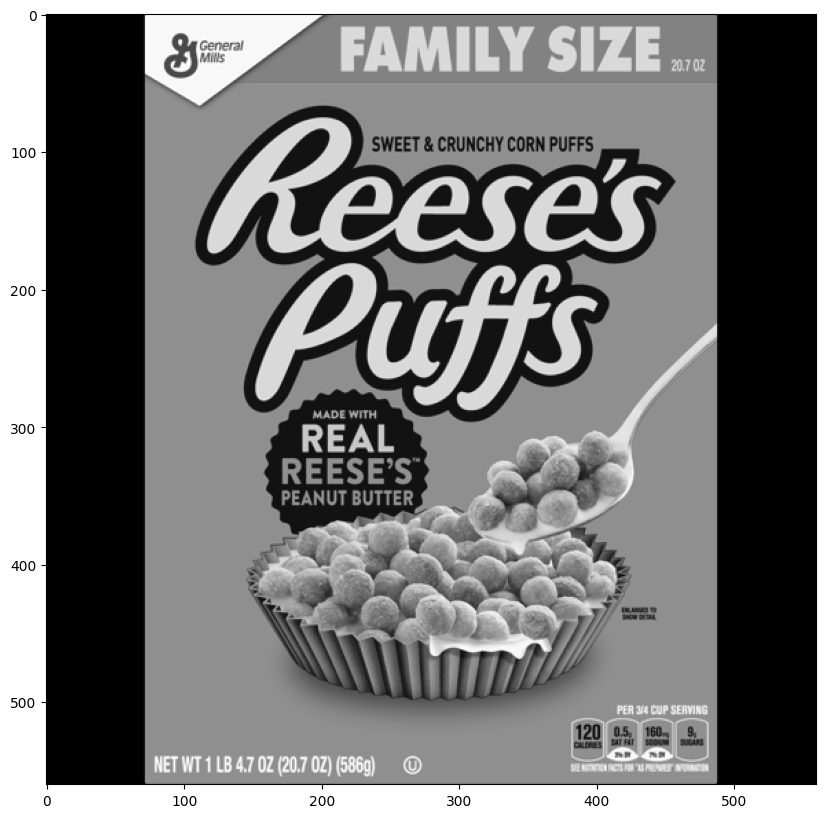

In [122]:
reeses = cv2.imread("../DATA/reeses_puffs.png", 0)
display(reeses)

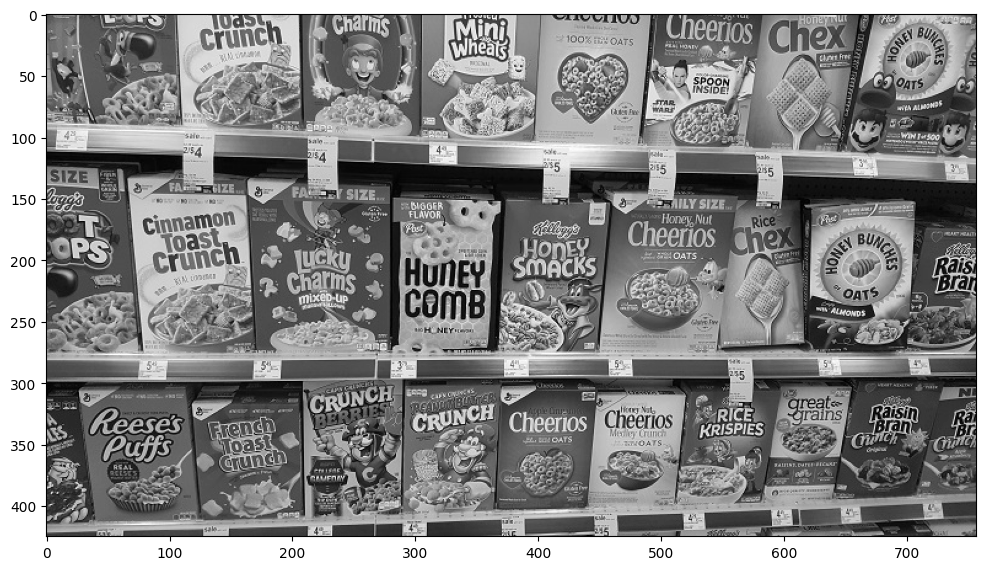

In [123]:
cereals = cv2.imread("../DATA/many_cereals.jpg", 0)
display(cereals)

In [124]:
orb = cv2.ORB_create()
kp1, des1 = orb.detectAndCompute(reeses, None)

In [125]:
kp2, des2 = orb.detectAndCompute(cereals, None)

In [126]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=2)
matches = bf.match(des1, des2)


In [127]:
single = matches[0]
single.distance

58.0

In [128]:
matches = sorted(matches, key=lambda x:x.distance)


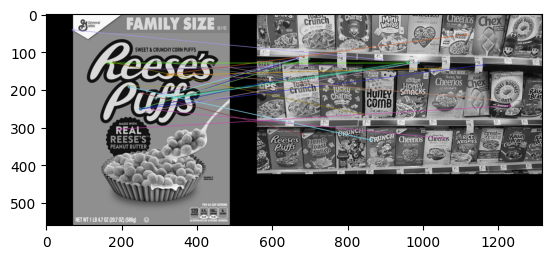

In [129]:
reeses_matches = cv2.drawMatches(reeses, kp1, cereals, kp2,matches[:25], None, flags=2)
plt.imshow(reeses_matches)

In [130]:
sift = cv2.xfeatures2d.SIFT_create()
kp1, des1 = sift.detectAndCompute(reeses, None)
kp2, des2 = sift.detectAndCompute(cereals, None)

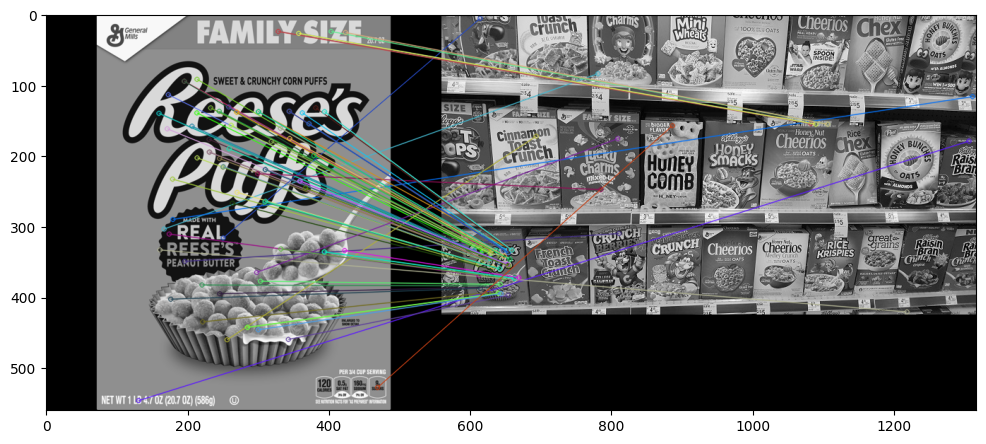

In [131]:
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)
good = []

# ratio test
for match1, match2 in matches:
    if match1.distance < (0.75 * match2.distance):
        good.append([match1])
len(good)
len(matches)
sift_matches = cv2.drawMatchesKnn(reeses, kp1, cereals, kp2, good, None, flags=2)
display(sift_matches)


In [132]:
sift = cv2.xfeatures2d.SIFT_create()
kp1, des1 = sift.detectAndCompute(reeses, None)
kp2, des2 = sift.detectAndCompute(cereals, None)
# FLANN
FLANN_INDEX_KDTREE = 0
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)


In [133]:
FLANN = cv2.FlannBasedMatcher(index_params, search_params)
matches = FLANN.knnMatch(des1, des2, k=2)


In [134]:
good = []
for match1, match2 in matches:
    if match1.distance < .75 * match2.distance:
        good.append([match1])
flann_matches = cv2.drawMatchesKnn(reeses, kp1)


error: OpenCV(4.12.0) :-1: error: (-5:Bad argument) in function 'drawMatchesKnn'
> Overload resolution failed:
>  - drawMatchesKnn() missing required argument 'img2' (pos 3)
>  - drawMatchesKnn() missing required argument 'img2' (pos 3)


In [ ]:
flann_matches = cv2.drawMatchesKnn(reeses, kp1, cereals, kp2, good, None, flags=0)
display(flann_matches)

# Did not finish 100% of this lecture. Start at about 13:26 to continue 